# CUSTOMER SEGMENTATION PROJECT
# RFM Analysis + K-Means Clustering
# ============================================
#
# **PROJECT OVERVIEW:**
# This project helps an online retail business understand their customers
# by grouping them into segments based on purchasing behavior.
#   
# **BUSINESS PROBLEM:**
# The company wants to:
# 1. Identify their most valuable customers
# 2. Find customers who might leave (At Risk)
# 3. Create targeted marketing strategies for each
#   
# **DATA SOURCE:**
# Online Retail II dataset (UCI) - 1M+ transactions from UK retailer
# Columns: Customer ID, Invoice, InvoiceDate, Quantity, Price, Country
#   
# **APPROACH:**
# 1. Data Cleaning - Remove missing values and returns
# 2. RFM Analysis - Calculate Recency, Frequency, Monetary
# 3. Customer Segmentation - Group customers using business rules
# 4. K-Means Clustering - Validate segments using ML
# 5. Business Recommendations - Actionable strategies per segment

#  IMPORT REQUIRED LIBRARIES

In [80]:
# Import all the libraries we need for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans      # For customer segmentation algorithm
from sklearn.preprocessing import StandardScaler  # For scaling data
import warnings
warnings.filterwarnings('ignore')  # Hide warning messages for cleaner output


##Load and Explore the Dataset

In [81]:
# Load the CSV file
df = pd.read_csv('/content/online_retail_II.csv')

In [82]:
# Basic information about the dataset

print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")
print(f"\nColumn names: {df.columns.tolist()}")

Number of rows: 1,067,371
Number of columns: 8

Column names: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [83]:
# Show first 5 rows
print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [84]:
# Show data types of each column
print(df.dtypes)

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


##Data Cleaning

In [85]:
# Check for missing values before cleaning

print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [86]:
# Store original size
original_size = len(df)
print(f"\nOriginal dataset size: {original_size:,} rows")


Original dataset size: 1,067,371 rows


In [87]:
# 1. Remove rows without Customer ID (we need these for segmentation)
before_count = len(df)
df = df.dropna(subset=['Customer ID'])
after_count = len(df)
print(f"\n1. Removed {before_count - after_count:,} rows with missing Customer IDs")

# 2. Remove returns (negative quantities mean canceled/returned orders)
before_count = len(df)
df = df[df['Quantity'] > 0]
after_count = len(df)
print(f"2. Removed {before_count - after_count:,} rows with negative quantities (returns)")

# 3. Remove rows with zero or negative prices
before_count = len(df)
df = df[df['Price'] > 0]
after_count = len(df)
print(f"3. Removed {before_count - after_count:,} rows with invalid prices")

# 4. Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 5. Create a new column: Total Price (Quantity × Price)
df['TotalPrice'] = df['Quantity'] * df['Price']

print("\n✅ Data cleaning complete!")
print(f"📊 Final dataset size: {len(df):,} rows")
print(f"👥 Number of unique customers: {df['Customer ID'].nunique():,}")
print(f"📅 Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")


1. Removed 243,007 rows with missing Customer IDs
2. Removed 18,744 rows with negative quantities (returns)
3. Removed 71 rows with invalid prices

✅ Data cleaning complete!
📊 Final dataset size: 805,549 rows
👥 Number of unique customers: 5,878
📅 Date range: 2009-12-01 to 2011-12-09


 ## STEP 4: RFM ANALYSIS

In [88]:
print("\n" + "="*70)
print("RFM ANALYSIS")
print("="*70)

# 4.1: Find the last transaction date in dataset
last_date = df['InvoiceDate'].max()
print(f"\n📅 Reference date (last transaction): {last_date.date()}")

# 4.2: Calculate RFM for each customer
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (last_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                 # Frequency
    'TotalPrice': 'sum'                                   # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalPrice': 'Monetary'
})

print(f"\n✅ RFM calculated for {len(rfm):,} customers")

# 4.3: View sample of RFM data
print("\n📋 Sample of RFM data (first 5 customers):")
print(rfm.head())

# 4.4: Statistical summary of RFM
print("\n📊 RFM Statistical Summary:")
print(rfm.describe())


RFM ANALYSIS

📅 Reference date (last transaction): 2011-12-09

✅ RFM calculated for 5,878 customers

📋 Sample of RFM data (first 5 customers):
             Recency  Frequency  Monetary
Customer ID                              
12346.0          325         12  77556.46
12347.0            1          8   5633.32
12348.0           74          5   2019.40
12349.0           18          4   4428.69
12350.0          309          1    334.40

📊 RFM Statistical Summary:
           Recency    Frequency       Monetary
count  5878.000000  5878.000000    5878.000000
mean    200.331916     6.289384    3018.616737
std     209.338707    13.009406   14737.731040
min       0.000000     1.000000       2.950000
25%      25.000000     1.000000     348.762500
50%      95.000000     3.000000     898.915000
75%     379.000000     7.000000    2307.090000
max     738.000000   398.000000  608821.650000


## STEP 5: RFM SCORING

In [89]:
# ============================================
# STEP 5: RFM SCORING (1-4 Scale)
# ============================================

print("\n" + "="*70)
print("RFM SCORING")
print("="*70)

# 5.1: Create individual scores (4 = best, 1 = worst)
# For Recency: Lower days = better
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=['4', '3', '2', '1'])

# For Frequency: Higher count = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=['1', '2', '3', '4'])

# For Monetary: Higher amount = better
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=['1', '2', '3', '4'])

# 5.2: Combine scores into single RFM Score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("\n✅ RFM Scores created!")
print("\n📋 Sample of RFM Scores:")
print(rfm[['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))

# 5.3: Score distribution
print("\n📊 RFM Score Distribution (Top 10 combinations):")
print(rfm['RFM_Score'].value_counts().head(10))


RFM SCORING

✅ RFM Scores created!

📋 Sample of RFM Scores:
             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
Customer ID                                                                
12346.0          325         12  77556.46       2       4       4       244
12347.0            1          8   5633.32       4       4       4       444
12348.0           74          5   2019.40       3       3       3       333
12349.0           18          4   4428.69       4       3       4       434
12350.0          309          1    334.40       2       1       1       211
12351.0          374          1    300.93       2       1       1       211
12352.0           35         10   2849.84       3       4       4       344
12353.0          203          2    406.76       2       2       2       222
12354.0          231          1   1079.40       2       1       3       213
12355.0          213          2    947.61       2       2       3       223

📊 RFM Score Distribution (

## STEP 6: CUSTOMER SEGMENTATION

In [90]:
# ============================================
# STEP 6: CUSTOMER SEGMENTATION (Business Rules)
# ============================================

print("\n" + "="*70)
print("CUSTOMER SEGMENTATION")
print("="*70)

# 6.1: Define segment classification function
def classify_customer(row):
    """
    Classifies customers based on their RFM scores.

    Segmentation Logic:
    - Champions: Best customers (high recency, frequency, monetary)
    - Loyal: Good, consistent customers
    - At Risk: Used to be good but haven't bought recently
    - Hibernating: Inactive for long time
    - New: Recent but few purchases
    - Potential: Shows promise but needs nurturing
    """
    if row['RFM_Score'] in ['444', '443', '434', '344']:
        return '👑 Champions'
    elif row['RFM_Score'] in ['442', '441', '432', '431', '433']:
        return '⭐ Loyal Customers'
    elif row['R_Score'] in ['1', '2'] and row['F_Score'] in ['3', '4']:
        return '⚠️ At Risk'
    elif row['R_Score'] in ['1', '2'] and row['F_Score'] in ['1', '2']:
        return '😴 Hibernating'
    elif row['R_Score'] in ['3', '4'] and row['F_Score'] in ['1', '2']:
        return '🆕 New Customers'
    else:
        return '📈 Potential Loyalists'

# 6.2: Apply classification
rfm['Segment'] = rfm.apply(classify_customer, axis=1)

# 6.3: View segment distribution
print("\n📊 Customer Distribution by Segment:")
segment_counts = rfm['Segment'].value_counts()
print(segment_counts)
print(f"\n✅ Total customers segmented: {len(rfm):,}")


CUSTOMER SEGMENTATION

📊 Customer Distribution by Segment:
Segment
😴 Hibernating            2045
👑 Champions              1182
🆕 New Customers           894
⚠️ At Risk                880
📈 Potential Loyalists     540
⭐ Loyal Customers         337
Name: count, dtype: int64

✅ Total customers segmented: 5,878


## STEP 7: K-MEANS CLUSTERING (Machine Learning)

In [91]:
# ============================================
# STEP 7: K-MEANS CLUSTERING
# ============================================

print("\n" + "="*70)
print("K-MEANS CLUSTERING (Machine Learning Approach)")
print("="*70)

# 7.1: Prepare data for clustering
rfm_cluster = rfm[['Recency', 'Frequency', 'Monetary']].copy()

print("\n📊 Data prepared for clustering:")
print(f"   Shape: {rfm_cluster.shape}")
print(f"   Features: Recency, Frequency, Monetary")

# 7.2: Standardize the data (important for K-Means)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_cluster)

print("\n✅ Data standardized (mean=0, standard deviation=1)")

# 7.3: Find optimal number of clusters using Elbow Method
inertias = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

# 7.4: Apply K-Means with chosen k (4 clusters)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 7.5: Name clusters based on characteristics
def name_cluster(row):
    if row['Monetary'] > rfm['Monetary'].quantile(0.75):
        return 'High Value'
    elif row['Monetary'] > rfm['Monetary'].median():
        return 'Medium Value'
    elif row['Recency'] > rfm['Recency'].quantile(0.75):
        return 'Inactive'
    else:
        return 'Low Value'

rfm['ML_Segment'] = rfm.apply(name_cluster, axis=1)

print(f"\n✅ K-Means clustering completed with {optimal_k} clusters")
print("\n📊 ML Segment Distribution:")
print(rfm['ML_Segment'].value_counts())


K-MEANS CLUSTERING (Machine Learning Approach)

📊 Data prepared for clustering:
   Shape: (5878, 3)
   Features: Recency, Frequency, Monetary

✅ Data standardized (mean=0, standard deviation=1)

✅ K-Means clustering completed with 4 clusters

📊 ML Segment Distribution:
ML_Segment
Low Value       1761
High Value      1470
Medium Value    1469
Inactive        1178
Name: count, dtype: int64



CLUSTERING SEGMENTS VISUALIZATIONS


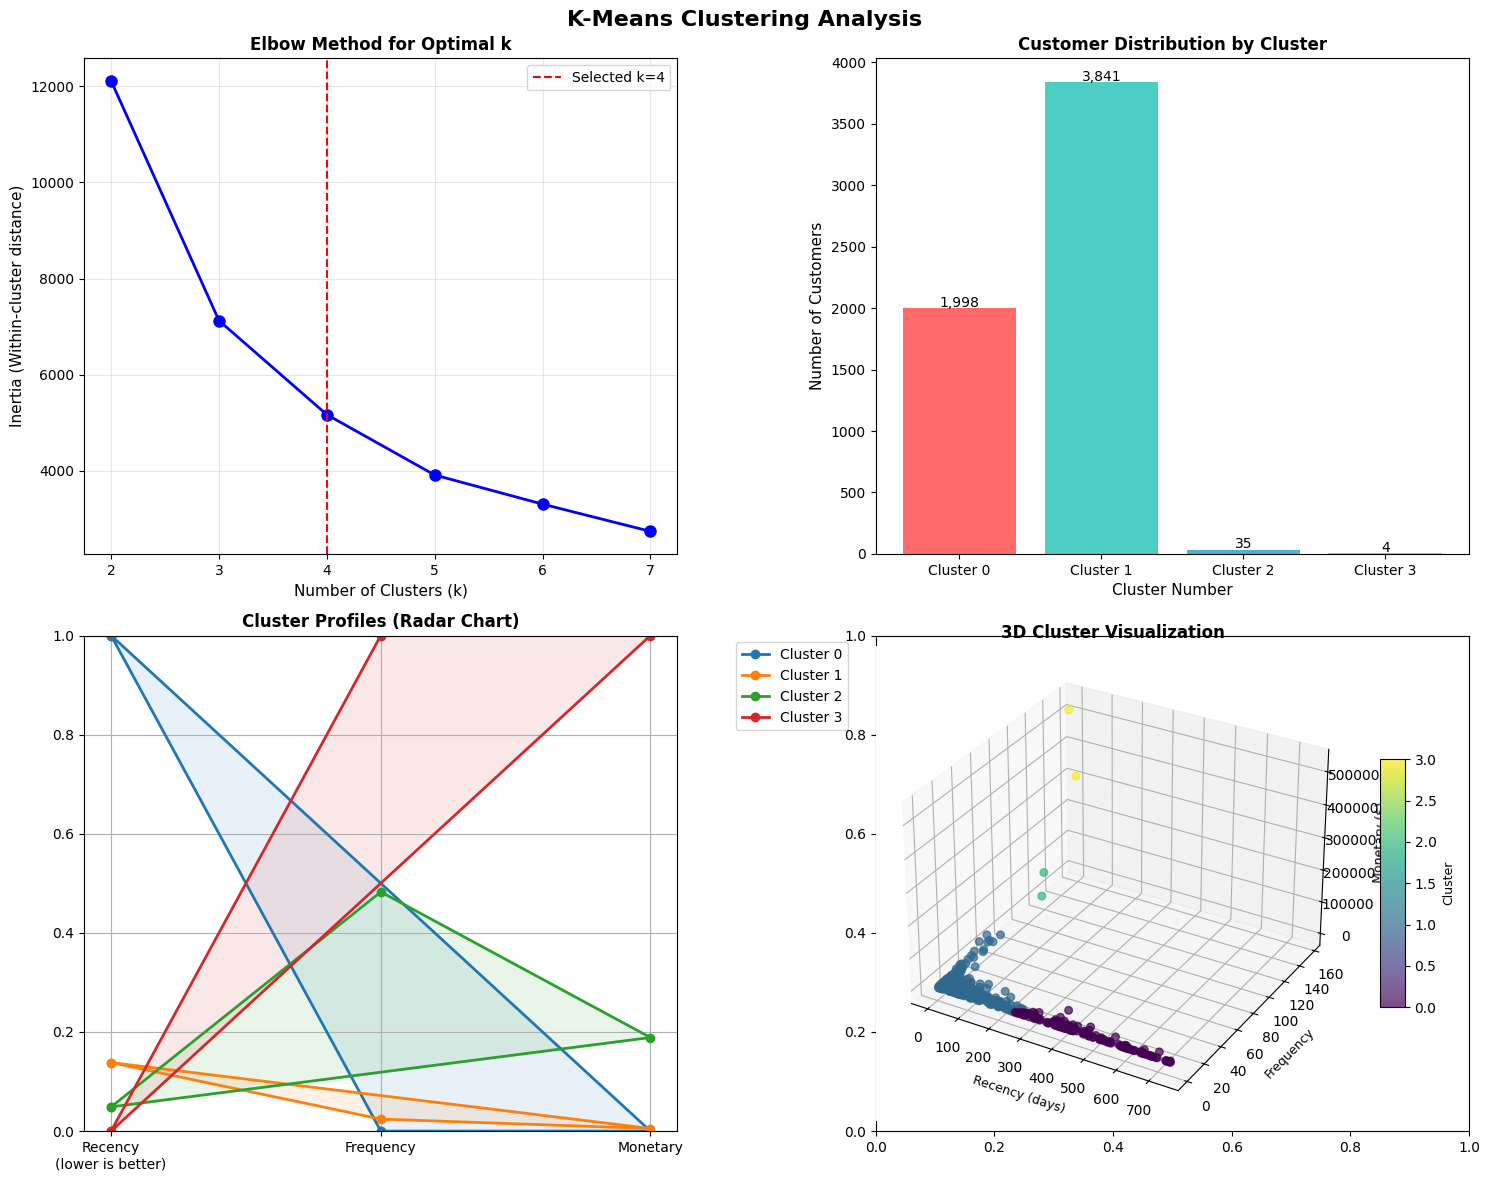

✅ All clustering visualizations created!


In [92]:
# ============================================
# CLUSTERING VISUALIZATIONS
# ============================================

print("\n" + "="*70)
print("CLUSTERING SEGMENTS VISUALIZATIONS")
print("="*70)

# Create a figure with 4 clustering charts
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('K-Means Clustering Analysis', fontsize=16, fontweight='bold')

# ============================================
# CHART 1: Elbow Method (Shows why we chose 4 clusters)
# ============================================

ax1 = axes[0, 0]
k_range = range(2, 8)
# Note: You need to have calculated inertias earlier
# If not, run this first:
inertias = []
for k in range(2, 8):
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(rfm_scaled)
    inertias.append(kmeans_test.inertia_)

ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia (Within-cluster distance)', fontsize=11)
ax1.set_title('Elbow Method for Optimal k', fontsize=12, fontweight='bold')
ax1.axvline(x=4, color='red', linestyle='--', label='Selected k=4')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ============================================
# CHART 2: Cluster Distribution (Bar Chart)
# ============================================

ax2 = axes[0, 1]
cluster_counts = rfm['Cluster'].value_counts().sort_index()
colors_cluster = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = ax2.bar(cluster_counts.index, cluster_counts.values, color=colors_cluster)
ax2.set_xlabel('Cluster Number', fontsize=11)
ax2.set_ylabel('Number of Customers', fontsize=11)
ax2.set_title('Customer Distribution by Cluster', fontsize=12, fontweight='bold')
ax2.set_xticks([0, 1, 2, 3])
ax2.set_xticklabels(['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])

# Add count labels on bars
for bar, count in zip(bars, cluster_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count:,}', ha='center', fontsize=10)

# ============================================
# CHART 3: Cluster Profiles (Radar Chart - Impressive!)
# ============================================

ax3 = axes[1, 0]
# Calculate cluster profiles
cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Normalize for radar chart (0-1 scale)
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler()
cluster_profiles_normalized = scaler_radar.fit_transform(cluster_profiles)

# Radar chart setup
categories = ['Recency\n(lower is better)', 'Frequency', 'Monetary']
N = len(categories)
angles = [n / float(N) * 2 * 3.14159 for n in range(N)]
angles += angles[:1]  # Close the loop

for i, cluster in enumerate(cluster_profiles.index):
    values = cluster_profiles_normalized[i].tolist()
    values += values[:1]  # Close the loop
    ax3.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}')
    ax3.fill(angles, values, alpha=0.1)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories, fontsize=10)
ax3.set_ylim(0, 1)
ax3.set_title('Cluster Profiles (Radar Chart)', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax3.grid(True)

# ============================================
# CHART 4: 3D Scatter Plot of Clusters (Most Impressive!)
# ============================================

ax4 = axes[1, 1]
# Use a subset for 3D plot (max 500 points for performance)
sample_size = min(500, len(rfm))
rfm_sample = rfm.sample(sample_size, random_state=42)

# Create 3D plot
from mpl_toolkits.mplot3d import Axes3D
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

scatter = ax4.scatter(rfm_sample['Recency'],
                       rfm_sample['Frequency'],
                       rfm_sample['Monetary'],
                       c=rfm_sample['Cluster'],
                       cmap='viridis',
                       s=30,
                       alpha=0.7)

ax4.set_xlabel('Recency (days)', fontsize=9)
ax4.set_ylabel('Frequency', fontsize=9)
ax4.set_zlabel('Monetary ($)', fontsize=9)
ax4.set_title('3D Cluster Visualization', fontsize=12, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax4, shrink=0.5, aspect=10)
cbar.set_label('Cluster', fontsize=9)

plt.tight_layout()
plt.show()

print("✅ All clustering visualizations created!")

## STEP 8: BUSINESS INSIGHTS

In [93]:
# ============================================
# STEP 8: BUSINESS INSIGHTS & ANALYSIS (CORRECTED)
# ============================================

print("\n" + "="*70)
print("BUSINESS INSIGHTS")
print("="*70)

# 8.1: Segment performance analysis
# Fixed: Using the actual index name instead of 'Customer ID'
segment_performance = rfm.groupby('Segment').agg({
    'Monetary': ['sum', 'mean'],
    'Frequency': 'mean',
    'Recency': 'mean'
}).round(2)

segment_performance.columns = ['Total_Revenue', 'Avg_Spend', 'Avg_Frequency', 'Avg_Recency']

# Add customer count separately
customer_counts = rfm.groupby('Segment').size()
segment_performance['Customer_Count'] = customer_counts

# Add percentage columns
segment_performance['Revenue_%'] = (segment_performance['Total_Revenue'] / segment_performance['Total_Revenue'].sum() * 100).round(1)
segment_performance['Customer_%'] = (segment_performance['Customer_Count'] / segment_performance['Customer_Count'].sum() * 100).round(1)

# Sort by revenue
segment_performance = segment_performance.sort_values('Total_Revenue', ascending=False)

print("\n📊 Segment Performance Matrix:")
print(segment_performance)

# 8.2: Pareto Analysis (80/20 rule)
top_segments = segment_performance.head(2)
print(f"\n📈 PARETO INSIGHT:")
print(f"   {top_segments['Customer_%'].sum():.1f}% of customers generate {top_segments['Revenue_%'].sum():.1f}% of revenue")


BUSINESS INSIGHTS

📊 Segment Performance Matrix:
                       Total_Revenue  Avg_Spend  Avg_Frequency  Avg_Recency  \
Segment                                                                       
👑 Champions              12289134.80   10396.90          18.71        21.62   
⚠️ At Risk                2221679.29    2524.64           6.53       276.12   
😴 Hibernating             1135329.16     555.17           1.49       410.56   
📈 Potential Loyalists      952765.39    1764.38           5.41        54.92   
🆕 New Customers            769953.17     861.25           1.78        39.72   
⭐ Loyal Customers          374567.36    1111.48           4.64        12.58   

                       Customer_Count  Revenue_%  Customer_%  
Segment                                                       
👑 Champions                      1182       69.3        20.1  
⚠️ At Risk                        880       12.5        15.0  
😴 Hibernating                    2045        6.4        34.8  
📈 

## STEP 9: VISUALIZATIONS


CREATING VISUALIZATIONS


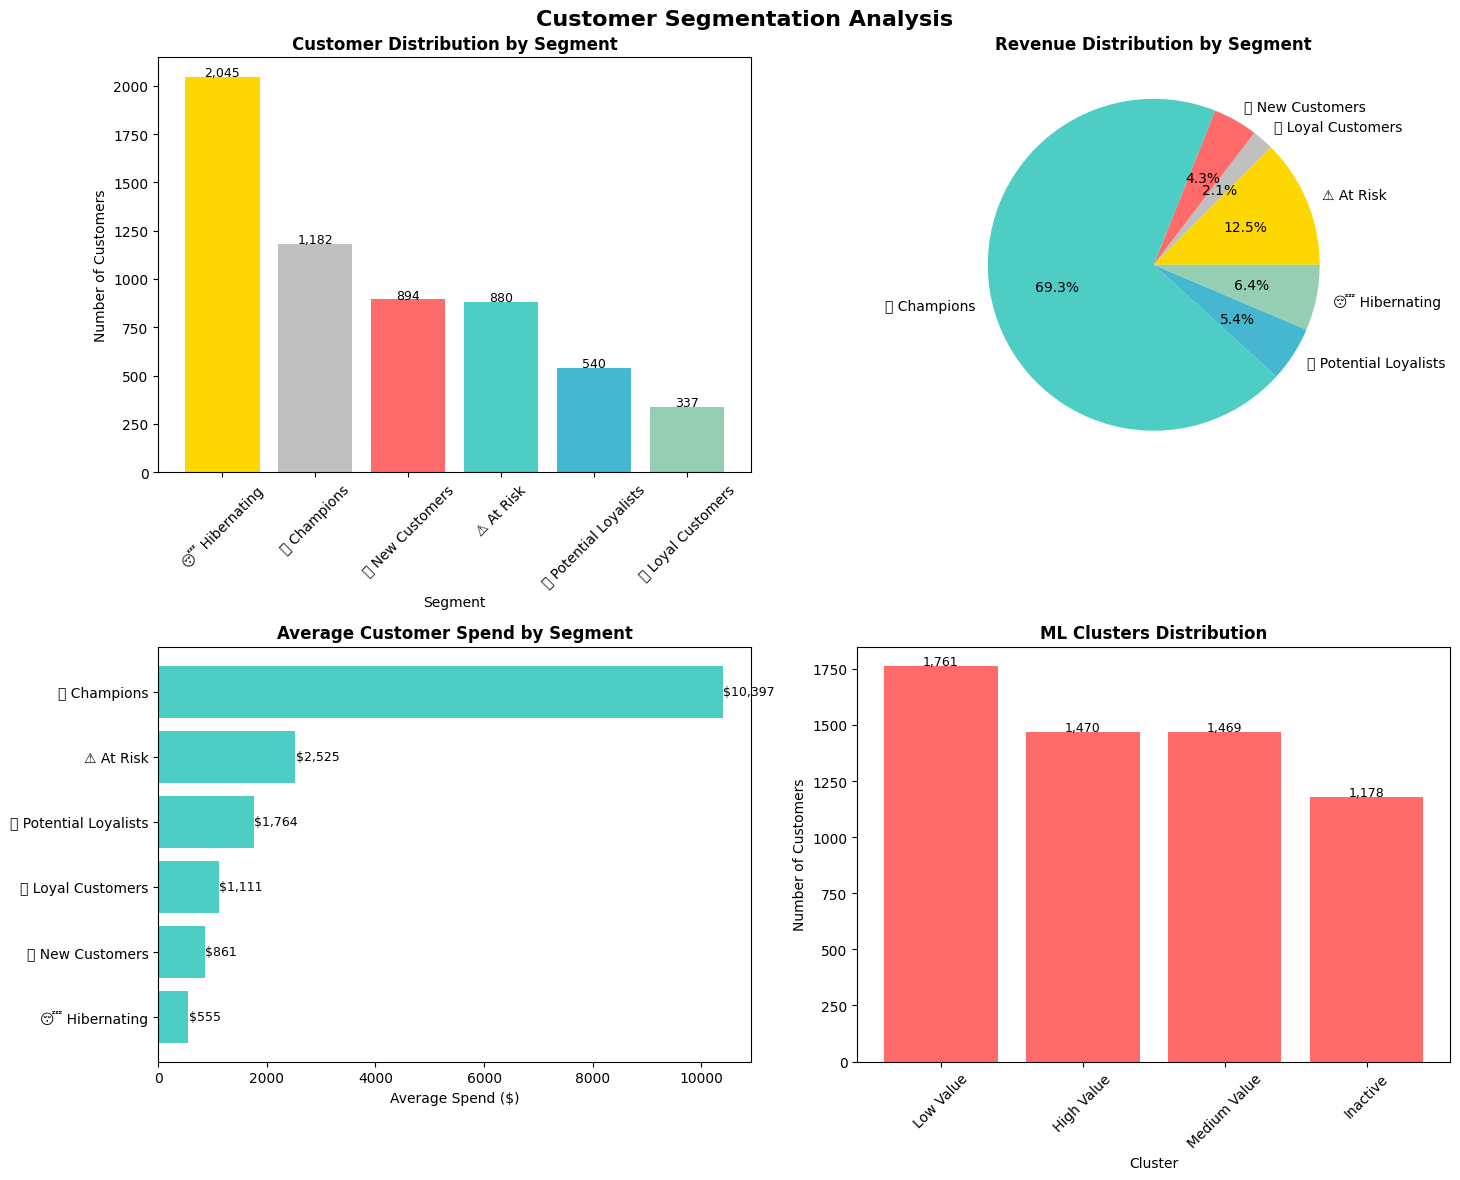

In [94]:
# ============================================
# STEP 9: VISUALIZATIONS
# ============================================

print("\n" + "="*70)
print("CREATING VISUALIZATIONS")
print("="*70)

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Customer Segmentation Analysis', fontsize=16, fontweight='bold')

# Chart 1: Customer Distribution by Segment
ax1 = axes[0, 0]
segment_counts = rfm['Segment'].value_counts()
colors = ['#FFD700', '#C0C0C0', '#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = ax1.bar(segment_counts.index, segment_counts.values, color=colors)
ax1.set_title('Customer Distribution by Segment', fontsize=12, fontweight='bold')
ax1.set_xlabel('Segment')
ax1.set_ylabel('Number of Customers')
ax1.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, segment_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count:,}', ha='center', fontsize=9)

# Chart 2: Revenue Distribution (Pie Chart)
ax2 = axes[0, 1]
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum()
ax2.pie(revenue_by_segment.values, labels=revenue_by_segment.index,
        autopct='%1.1f%%', colors=colors)
ax2.set_title('Revenue Distribution by Segment', fontsize=12, fontweight='bold')

# Chart 3: Average Spend by Segment
ax3 = axes[1, 0]
avg_spend = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=True)
bars = ax3.barh(avg_spend.index, avg_spend.values, color='#4ECDC4')
ax3.set_title('Average Customer Spend by Segment', fontsize=12, fontweight='bold')
ax3.set_xlabel('Average Spend ($)')
for bar, spend in zip(bars, avg_spend.values):
    ax3.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'${spend:,.0f}', va='center', fontsize=9)

# Chart 4: ML Cluster Distribution
ax4 = axes[1, 1]
ml_counts = rfm['ML_Segment'].value_counts()
bars = ax4.bar(ml_counts.index, ml_counts.values, color='#FF6B6B')
ax4.set_title('ML Clusters Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Cluster')
ax4.set_ylabel('Number of Customers')
ax4.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, ml_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


##  STEP 10: BUSINESS RECOMMENDATIONS

In [95]:
# Define strategies for each segment
strategies = {
    '👑 Champions': {
        'priority': 'Highest',
        'goal': 'Retain and delight',
        'actions': [
            'Create VIP loyalty program with exclusive benefits',
            'Offer early access to new products',
            'Provide dedicated customer support line',
            'Send personalized thank you notes and birthday gifts'
        ]
    },
    '⭐ Loyal Customers': {
        'priority': 'High',
        'goal': 'Increase frequency and referrals',
        'actions': [
            'Implement referral program ($20 credit for referrals)',
            'Create tiered rewards system (Silver, Gold, Platinum)',
            'Send personalized product recommendations based on history',
            'Offer free shipping on orders over $50'
        ]
    },
    '📈 Potential Loyalists': {
        'priority': 'Medium',
        'goal': 'Convert to loyal customers',
        'actions': [
            'Send educational content about products',
            'Offer cross-sell recommendations',
            'Provide free shipping on next 3 purchases',
            'Engage with email sequences every 2 weeks'
        ]
    },
    '⚠️ At Risk': {
        'priority': 'High',
        'goal': 'Win back before leaving',
        'actions': [
            'Send win-back campaign with 25% discount',
            'Proactive customer outreach via email',
            'Highlight new arrivals since last visit',
            'Send satisfaction survey with $5 incentive'
        ]
    },
    '😴 Hibernating': {
        'priority': 'Low',
        'goal': 'Re-engagement',
        'actions': [
            'Send re-engagement email sequence (3 emails over 6 weeks)',
            'Offer 30% reactivation discount',
            'Notify only during major sales events',
            'Ask for feedback: "Why did you stop shopping?"'
        ]
    },
    '🆕 New Customers': {
        'priority': 'Medium',
        'goal': 'First-time conversion to repeat',
        'actions': [
            'Send 3-part welcome email series',
            'Offer first-purchase discount (10-15%)',
            'Request product review with incentive',
            'Encourage social media following'
        ]
    }
}

# Display recommendations
for segment, data in strategies.items():
    if segment in rfm['Segment'].values:
        count = rfm[rfm['Segment'] == segment].shape[0]
        revenue = rfm[rfm['Segment'] == segment]['Monetary'].sum()

        print(f"\n{'='*70}")
        print(f"📌 {segment}")
        print(f"{'='*70}")
        print(f"   👥 Customers: {count:,}")
        print(f"   💰 Revenue: ${revenue:,.2f}")
        print(f"   🎯 Priority: {data['priority']}")
        print(f"   🎯 Goal: {data['goal']}")
        print(f"\n   ✅ Recommended Actions:")
        for action in data['actions']:
            print(f"      • {action}")

print("\n" + "="*70)
print("IMPACT ESTIMATE")
print("="*70)
print("""
If implemented, these strategies could:
• Increase customer retention by 15-20%
• Improve revenue from At Risk customers by 25%
• Increase Customer Lifetime Value (CLV) by 30%
• Reduce customer churn by 10%
""")


📌 👑 Champions
   👥 Customers: 1,182
   💰 Revenue: $12,289,134.80
   🎯 Priority: Highest
   🎯 Goal: Retain and delight

   ✅ Recommended Actions:
      • Create VIP loyalty program with exclusive benefits
      • Offer early access to new products
      • Provide dedicated customer support line
      • Send personalized thank you notes and birthday gifts

📌 ⭐ Loyal Customers
   👥 Customers: 337
   💰 Revenue: $374,567.36
   🎯 Priority: High
   🎯 Goal: Increase frequency and referrals

   ✅ Recommended Actions:
      • Implement referral program ($20 credit for referrals)
      • Create tiered rewards system (Silver, Gold, Platinum)
      • Send personalized product recommendations based on history
      • Offer free shipping on orders over $50

📌 📈 Potential Loyalists
   👥 Customers: 540
   💰 Revenue: $952,765.39
   🎯 Priority: Medium
   🎯 Goal: Convert to loyal customers

   ✅ Recommended Actions:
      • Send educational content about products
      • Offer cross-sell recommendations


## STEP 11: EXPORT RESULTS

In [96]:
# ============================================
# STEP 11: EXPORT RESULTS FOR DASHBOARD
# ============================================

print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# IMPORTANT: This is required for Google Colab download
from google.colab import files
# Prepare export file
export_df = rfm.reset_index()
export_df = export_df[['Customer ID', 'Recency', 'Frequency', 'Monetary',
                        'R_Score', 'F_Score', 'M_Score', 'RFM_Score',
                        'Segment', 'ML_Segment', 'Cluster']]

# Save to CSV
export_df.to_csv('customer_segmentation_cleaned.csv', index=False)
print("✅ Results saved to 'customer_segmentation_cleaned.csv'")

# Download file (Google Colab)
files.download('customer_segmentation_cleaned.csv')

print("\n📋 Export file contains:")
print(f"   • {len(export_df):,} customers")
print(f"   • {len(export_df.columns)} columns including:")
print(f"     - Customer ID (identifier)")
print(f"     - RFM metrics (Recency, Frequency, Monetary)")
print(f"     - RFM Scores (1-4 scale)")
print(f"     - Business Segments")
print(f"     - ML Clusters")


EXPORTING RESULTS
✅ Results saved to 'customer_segmentation_cleaned.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📋 Export file contains:
   • 5,878 customers
   • 11 columns including:
     - Customer ID (identifier)
     - RFM metrics (Recency, Frequency, Monetary)
     - RFM Scores (1-4 scale)
     - Business Segments
     - ML Clusters
